# Erosion Rate Prediction — 2026-03-03

## Framing

Previous notebooks predicted bank **position** (dist) directly. That approach had two flaws:

1. **Wrong target.** Predicting raw position conflates the initial distance from the centreline with the erosion behaviour. A bank at 50 m and one at 150 m look very different even if they erode at the same rate.
2. **Wrong input feature.** Using the mean of *all* historical velocities dilutes the signal. The most informative input is the *most recently observed* erosion rate — the last period's behaviour.

**Correct framing:**

> Input = last observed erosion rate → Target = next period erosion rate

Bank position is a *derived output*, computed after the velocity prediction.

## Variable definitions

For a region with timestamps sorted as `[…, t1, t2, t3]` where `t3` is held out:

| Variable | Definition |
|---|---|
| `v_train` | `(dist_t2 − dist_t1) / (year_t2 − year_t1)` — most recent *training* period erosion rate (m/yr) |
| `v_test`  | `(dist_t3 − dist_t2) / (year_t3 − year_t2)` — held-out *test* period erosion rate (m/yr) |
| `dist_t2` | last known bank position (m from centreline) |
| `dist_t3` | actual bank position at test year |

Positive velocity = erosion (bank retreating from centreline).  
Negative velocity = accretion (bank advancing toward centreline).

## Structure

1. Setup
2. Load & prepare data — build `region_split.parquet` (fixed for all future experiments)
3. Data exploration — velocity distributions by cluster
4. Model 0: Naive persistence (`v_predicted = v_train`)
5. Model 1: Cross-regional linear regression (`v_test ~ α + β × v_train`)
6. Comparison — velocity MAE + position MAE
7. Next steps

---

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

import src.paths as PATHS
import src.constants as CONST

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

DIST_COL = CONST.DISTANCE_TO_EROSION_BORDER
CLUSTERS = ['ijssel1', 'ijssel2', 'maas1', 'maas2', 'maas3', 'nederrijn', 'rijn']

def get_cluster(location_id: str) -> str:
    for c in CLUSTERS:
        if location_id.startswith(c):
            return c
    return 'other'

print('✅ Imports OK')

✅ Imports OK


## 2. Load & Prepare Data

For each region with ≥ 3 timestamps:
- `t1`, `t2` = the two most recent **training** timestamps
- `t3` = the **held-out** test timestamp (the last one)

We extract `v_train`, `v_test`, and related fields, then **save the split** so all future experiments use identical train/test sets.

In [2]:
# Load the fixed train/test split produced by 20260303_create_region_split.ipynb
# Run that notebook first if region_split.parquet does not yet exist.
SPLIT_PATH = PATHS.DATA_DIR / '02_processed/erosion/region_split.parquet'

split = pd.read_parquet(SPLIT_PATH)

train = split[split['split'] == 'train']
test  = split[split['split'] == 'test']

print(f'Loaded region_split.parquet')
print(f'  Total  : {len(split):,} regions')
print(f'  Train  : {len(train):,}')
print(f'  Test   : {len(test):,}')
print(f'  Columns: {list(split.columns)}')
print(f'\nSample:')
print(split[['cluster','split','t1','t2','t3','v_train','v_test','dist_t2','dist_t3']].head(6).round(3))

Loaded region_split.parquet
  Total  : 9,402 regions
  Train  : 7,521
  Test   : 1,881
  Columns: ['cluster', 'n_timestamps', 't1', 't2', 't3', 'train_span_yr', 'test_span_yr', 'dist_t1', 'dist_t2', 'dist_t3', 'v_train', 'v_test', 'split', 'is_nvo']

Sample:
                     cluster  split    t1    t2    t3  v_train  v_test  \
location_id                                                              
ijssel1_l_0010_0020  ijssel1  train  2017  2022  2025    0.134  -0.056   
ijssel1_l_0020_0030  ijssel1   test  2017  2022  2025    3.750  -5.972   
ijssel1_l_0050_0056  ijssel1  train  2017  2022  2025   -0.033  -0.000   
ijssel1_l_0056_0060  ijssel1  train  2017  2022  2025    0.050   3.944   
ijssel1_l_0060_0070  ijssel1  train  2017  2022  2025   -0.417   0.111   
ijssel1_l_0070_0080  ijssel1  train  2017  2022  2025    0.000   0.000   

                     dist_t2  dist_t3  
location_id                            
ijssel1_l_0010_0020   94.973   94.806  
ijssel1_l_0020_0030  136.333

## 3. Data Exploration — Velocity distributions

Understanding the signal before modelling.

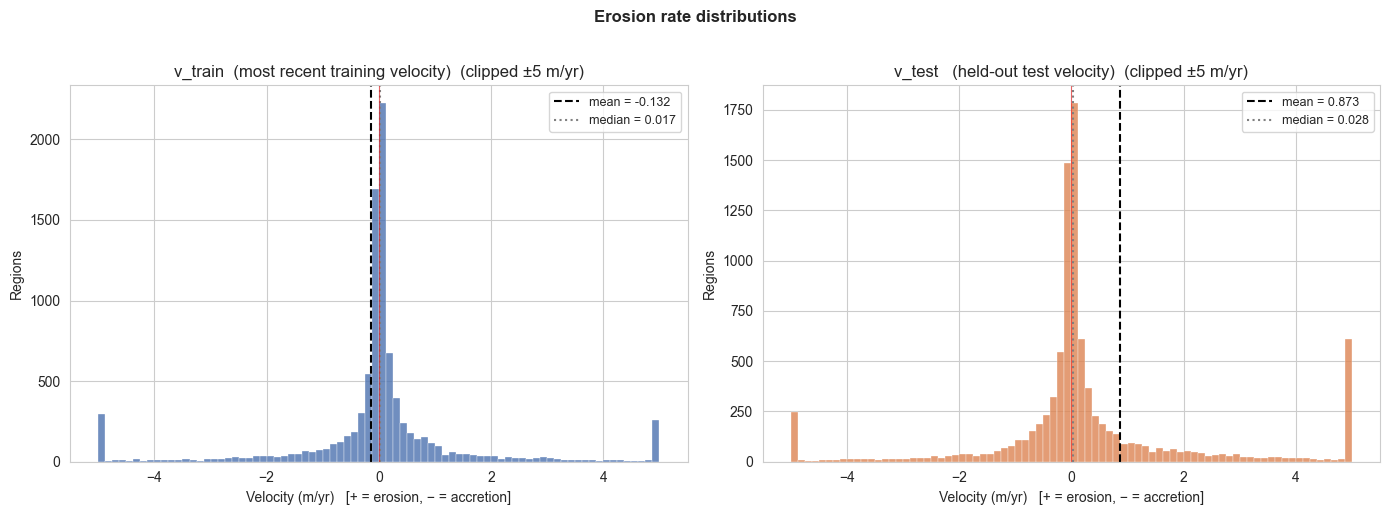


Velocity summary per cluster (m/yr):


v_train               v_test              
             mean median    std   mean median    std
cluster                                             
ijssel1     0.044  0.000  1.136  0.395  0.056  2.745
ijssel2    -0.127 -0.017  0.820 -0.015 -0.056  1.298
maas1      -0.123 -0.017  0.378  0.069  0.028  0.593
maas2       0.806 -0.017  3.954  1.855  0.197  6.422
maas3       0.050  0.017  1.505  0.132  0.028  2.108
nederrijn  -0.170  0.018  3.040  0.041 -0.000  3.900
rijn       -0.764  0.033  6.195  3.478  0.104  9.740

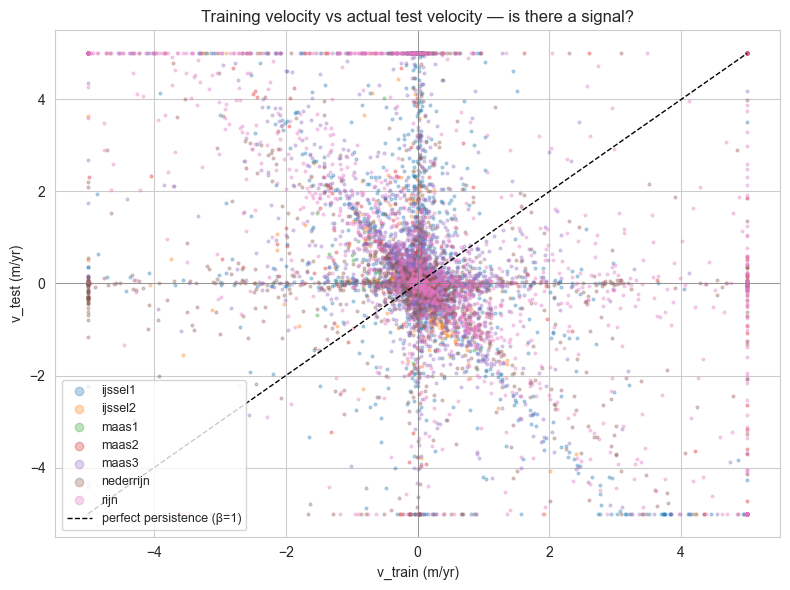


Pearson correlation v_train ↔ v_test: -0.588

Per-cluster correlation:
cluster
ijssel1     -0.398
ijssel2     -0.491
maas1       -0.480
maas2       -0.203
maas3       -0.544
nederrijn   -0.172
rijn        -0.711


In [3]:
# ── 3a. Overall v_train and v_test distributions ──────────────────────────────
CLIP = 5  # m/yr — clip extremes for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label, color in [
    (axes[0], 'v_train', 'v_train  (most recent training velocity)', '#4c72b0'),
    (axes[1], 'v_test',  'v_test   (held-out test velocity)',         '#dd8452'),
]:
    data = split[col].clip(-CLIP, CLIP)
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(split[col].mean(),   color='black', linestyle='--', linewidth=1.5, label=f'mean = {split[col].mean():.3f}')
    ax.axvline(split[col].median(), color='grey',  linestyle=':',  linewidth=1.5, label=f'median = {split[col].median():.3f}')
    ax.axvline(0, color='red', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Velocity (m/yr)   [+ = erosion, − = accretion]')
    ax.set_ylabel('Regions')
    ax.set_title(f'{label}  (clipped ±{CLIP} m/yr)')
    ax.legend(fontsize=9)

plt.suptitle('Erosion rate distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 3b. Per-cluster summary ───────────────────────────────────────────────────
print('\nVelocity summary per cluster (m/yr):')
cluster_summary = split.groupby('cluster')[['v_train','v_test']].agg(
    ['mean','median','std']
).round(3)
display(cluster_summary)

# ── 3c. Scatter v_train vs v_test — the core signal ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for cluster, group in split.groupby('cluster'):
    ax.scatter(
        group['v_train'].clip(-CLIP, CLIP),
        group['v_test'].clip(-CLIP, CLIP),
        s=4, alpha=0.3, label=cluster
    )
ax.plot([-CLIP, CLIP], [-CLIP, CLIP], 'k--', linewidth=1, label='perfect persistence (β=1)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel('v_train (m/yr)')
ax.set_ylabel('v_test (m/yr)')
ax.set_title('Training velocity vs actual test velocity — is there a signal?')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

# Pearson correlation
corr = split['v_train'].corr(split['v_test'])
print(f'\nPearson correlation v_train ↔ v_test: {corr:.3f}')
per_cluster_corr = split.groupby('cluster').apply(
    lambda g: g['v_train'].corr(g['v_test'])
).round(3).rename('correlation')
print('\nPer-cluster correlation:')
print(per_cluster_corr.to_string())

## 4. Evaluation Helpers

All models are evaluated with the same functions.

In [4]:
def evaluate(split_df: pd.DataFrame, v_predicted: pd.Series, model_name: str = 'Model') -> dict:
    """
    Evaluate a model on both velocity and position MAE.

    Parameters
    ----------
    split_df    : the region_split DataFrame (must include v_test, dist_t2, dist_t3, test_span_yr)
    v_predicted : predicted erosion rate (m/yr), aligned with split_df index
    model_name  : label for printing

    Returns
    -------
    dict of metrics, including predicted positions for further analysis
    """
    v_pred  = v_predicted.reindex(split_df.index)
    v_true  = split_df['v_test']

    # Derived position prediction
    dist_predicted = split_df['dist_t2'] + v_pred * split_df['test_span_yr']
    dist_true      = split_df['dist_t3']

    v_errors   = v_pred - v_true
    pos_errors = dist_predicted - dist_true

    metrics = {
        'model'           : model_name,
        'n'               : len(v_pred),
        # velocity
        'v_mae'           : float(v_errors.abs().mean()),
        'v_rmse'          : float(np.sqrt((v_errors**2).mean())),
        'v_bias'          : float(v_errors.mean()),
        'v_median_ae'     : float(v_errors.abs().median()),
        # position
        'pos_mae'         : float(pos_errors.abs().mean()),
        'pos_rmse'        : float(np.sqrt((pos_errors**2).mean())),
        'pos_bias'        : float(pos_errors.mean()),
        'pos_within_1m'   : float((pos_errors.abs() <= 1).mean()),
        'pos_within_5m'   : float((pos_errors.abs() <= 5).mean()),
        'pos_within_10m'  : float((pos_errors.abs() <= 10).mean()),
        # store predictions for plotting
        '_v_pred'         : v_pred,
        '_dist_predicted' : dist_predicted,
    }

    print(f'\n{'─'*55}')
    print(f'  {model_name}  (n={metrics["n"]:,})')
    print(f'{'─'*55}')
    print(f'  VELOCITY (m/yr)')
    print(f'    MAE         : {metrics["v_mae"]:>8.4f}')
    print(f'    RMSE        : {metrics["v_rmse"]:>8.4f}')
    print(f'    Bias        : {metrics["v_bias"]:>8.4f}  ({"over" if metrics["v_bias"]>0 else "under"}-predicts erosion)')
    print(f'    Median AE   : {metrics["v_median_ae"]:>8.4f}')
    print(f'  POSITION (m)')
    print(f'    MAE         : {metrics["pos_mae"]:>8.3f}')
    print(f'    RMSE        : {metrics["pos_rmse"]:>8.3f}')
    print(f'    Bias        : {metrics["pos_bias"]:>8.3f}')
    print(f'    Within  1 m : {metrics["pos_within_1m"]*100:>6.1f}%')
    print(f'    Within  5 m : {metrics["pos_within_5m"]*100:>6.1f}%')
    print(f'    Within 10 m : {metrics["pos_within_10m"]*100:>6.1f}%')

    return metrics


def plot_results(results_list: list, clip_v: float = 5, clip_pos: float = 30):
    """Side-by-side error distributions for velocity and position."""
    colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, r in enumerate(results_list):
        color = colors[i % len(colors)]
        v_ae   = (r['_v_pred'] - test['v_test']).abs().clip(0, clip_v)
        pos_ae = (r['_dist_predicted'] - test['dist_t3']).abs().clip(0, clip_pos)
        mae_v  = r['v_mae']
        mae_p  = r['pos_mae']
        label  = r['model']
        v_ae.hist(  bins=60, ax=axes[0], alpha=0.6, color=color, label=f'{label} (MAE={mae_v:.3f} m/yr)')
        pos_ae.hist(bins=60, ax=axes[1], alpha=0.6, color=color, label=f'{label} (MAE={mae_p:.2f} m)')

    axes[0].set_title(f'Velocity absolute error (clipped at {clip_v} m/yr)')
    axes[0].set_xlabel('|v_predicted − v_test|  (m/yr)')
    axes[0].legend()
    axes[1].set_title(f'Position absolute error (clipped at {clip_pos} m)')
    axes[1].set_xlabel('|dist_predicted − dist_t3|  (m)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


print('✅ Evaluation helpers defined.')

✅ Evaluation helpers defined.


## 5. Model 0 — Naive Persistence

Predict `v_predicted = v_train` — the last observed erosion rate simply continues.

No learning. This is the honest dumb baseline.

In [5]:
# Train on TRAIN set → evaluate on TEST set only
v_pred_naive  = test['v_train'].copy()
metrics_naive = evaluate(test, v_pred_naive, model_name='Model 0 — Naive persistence (v_pred = v_train)')


───────────────────────────────────────────────────────
  Model 0 — Naive persistence (v_pred = v_train)  (n=1,881)
───────────────────────────────────────────────────────
  VELOCITY (m/yr)
    MAE         :   3.2890
    RMSE        :   8.4100
    Bias        :  -1.2956  (under-predicts erosion)
    Median AE   :   0.6516
  POSITION (m)
    MAE         :   12.160
    RMSE        :   32.758
    Bias        :   -5.017
    Within  1 m :   37.2%
    Within  5 m :   65.8%
    Within 10 m :   78.4%


## 6. Model 1 — Cross-regional linear regression

```
v_test ~ α + β × v_train
```

One global model, trained on all regions simultaneously.

- If `β < 1`: erosion rates mean-revert — past velocity overstates future velocity
- If `β ≈ 1`: velocity is persistent — same as naive baseline
- If `β > 1`: rates accelerate over time

In [6]:
# Fit on TRAIN set
X_train = train[['v_train']].values
y_train = train['v_test'].values

lr = LinearRegression().fit(X_train, y_train)

print(f'Fitted model (on train set): v_test = {lr.intercept_:.4f} + {lr.coef_[0]:.4f} × v_train')
print(f'  α = {lr.intercept_:.4f} m/yr  (expected velocity when v_train = 0)')
print(f'  β = {lr.coef_[0]:.4f}          ({"mean-reversion" if lr.coef_[0] < 1 else "persistent/accelerating"})')

cv_r2 = cross_val_score(LinearRegression(), X_train, y_train, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')
print(f'  CV R² (5-fold, train): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

# Evaluate on TEST set
X_test    = test[['v_train']].values
v_pred_lr = pd.Series(lr.predict(X_test), index=test.index)
metrics_lr = evaluate(test, v_pred_lr, model_name='Model 1 — LR  (v_test ~ α + β × v_train)')

Fitted model (on train set): v_test = 0.6991 + -0.9501 × v_train
  α = 0.6991 m/yr  (expected velocity when v_train = 0)
  β = -0.9501          (mean-reversion)
  CV R² (5-fold, train): 0.344 ± 0.034

───────────────────────────────────────────────────────
  Model 1 — LR  (v_test ~ α + β × v_train)  (n=1,881)
───────────────────────────────────────────────────────
  VELOCITY (m/yr)
    MAE         :   2.0053
    RMSE        :   4.4815
    Bias        :  -0.2392  (under-predicts erosion)
    Median AE   :   0.7548
  POSITION (m)
    MAE         :    7.179
    RMSE        :   17.018
    Bias        :   -1.095
    Within  1 m :   10.7%
    Within  5 m :   75.0%
    Within 10 m :   84.8%


## 7. Comparison

In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────
cols_display = ['model','n','v_mae','v_rmse','v_bias','v_median_ae','pos_mae','pos_rmse','pos_bias','pos_within_5m','pos_within_10m']
summary = pd.DataFrame([{k: v for k, v in m.items() if not k.startswith('_')} for m in [metrics_naive, metrics_lr]])
display(summary[cols_display].round(4).set_index('model'))

# Improvement
v_improvement   = (metrics_naive['v_mae']   - metrics_lr['v_mae'])   / metrics_naive['v_mae']   * 100
pos_improvement = (metrics_naive['pos_mae'] - metrics_lr['pos_mae']) / metrics_naive['pos_mae'] * 100
print(f'\nVelocity MAE improvement  (LR vs Naive): {v_improvement:+.1f}%')
print(f'Position MAE improvement  (LR vs Naive): {pos_improvement:+.1f}%')

,n,v_mae,v_rmse,v_bias,v_median_ae,pos_mae,pos_rmse,pos_bias,pos_within_5m,pos_within_10m
model,,,,,,,,,,
Model 0 — Naive persistence (v_pred = v_train),1881,3.2890,8.4100,-1.2956,0.6516,12.1601,32.7582,-5.0169,0.6582,0.7842
Model 1 — LR (v_test ~ α + β × v_train),1881,2.0053,4.4815,-0.2392,0.7548,7.1795,17.0176,-1.0947,0.7501,0.8485



Velocity MAE improvement  (LR vs Naive): +39.0%
Position MAE improvement  (LR vs Naive): +41.0%


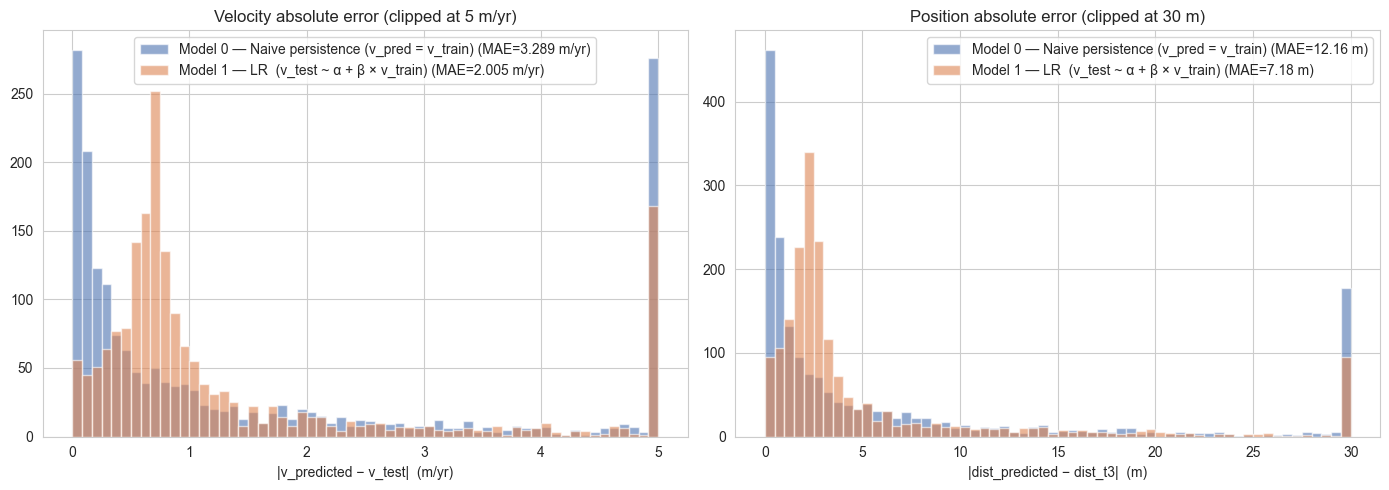

In [8]:
# ── Error distributions ────────────────────────────────────────────────────────
plot_results([metrics_naive, metrics_lr])

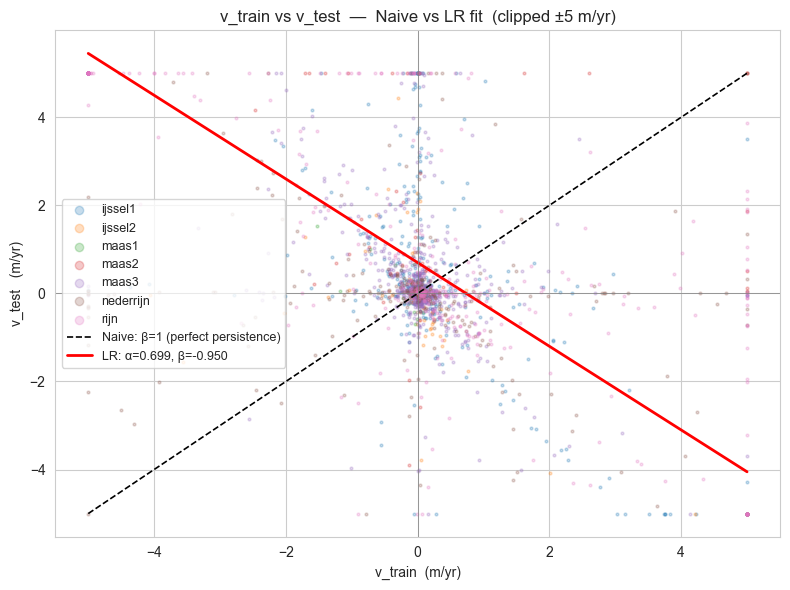

In [9]:
# ── Scatter: v_train vs v_test with fits ──────────────────────────────────────
CLIP = 5
fig, ax = plt.subplots(figsize=(8, 6))

for cluster, group in test.groupby('cluster'):
    ax.scatter(group['v_train'].clip(-CLIP, CLIP), group['v_test'].clip(-CLIP, CLIP),
               s=4, alpha=0.25, label=cluster)

x_range = np.linspace(-CLIP, CLIP, 200)
ax.plot(x_range, x_range,
        'k--', linewidth=1.2, label='Naive: β=1 (perfect persistence)')
ax.plot(x_range, lr.intercept_ + lr.coef_[0] * x_range,
        'r-',  linewidth=2,   label=f'LR: α={lr.intercept_:.3f}, β={lr.coef_[0]:.3f}')

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel('v_train  (m/yr)')
ax.set_ylabel('v_test   (m/yr)')
ax.set_title('v_train vs v_test  —  Naive vs LR fit  (clipped ±5 m/yr)')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# ── Per-cluster breakdown of LR improvement (TEST set only) ───────────────────
test_eval = test.copy()
test_eval['v_pred_naive'] = v_pred_naive
test_eval['v_pred_lr']    = v_pred_lr
test_eval['v_ae_naive']   = (test_eval['v_pred_naive'] - test_eval['v_test']).abs()
test_eval['v_ae_lr']      = (test_eval['v_pred_lr']    - test_eval['v_test']).abs()
test_eval['pos_ae_naive'] = (test_eval['dist_t2'] + test_eval['v_pred_naive'] * test_eval['test_span_yr'] - test_eval['dist_t3']).abs()
test_eval['pos_ae_lr']    = (test_eval['dist_t2'] + test_eval['v_pred_lr']    * test_eval['test_span_yr'] - test_eval['dist_t3']).abs()

cluster_eval = test_eval.groupby('cluster').agg(
    n             = ('v_test', 'count'),
    v_mae_naive   = ('v_ae_naive',   'mean'),
    v_mae_lr      = ('v_ae_lr',      'mean'),
    pos_mae_naive = ('pos_ae_naive', 'mean'),
    pos_mae_lr    = ('pos_ae_lr',    'mean'),
).round(3)
cluster_eval['v_improv_%']   = ((cluster_eval['v_mae_naive']   - cluster_eval['v_mae_lr'])   / cluster_eval['v_mae_naive']   * 100).round(1)
cluster_eval['pos_improv_%'] = ((cluster_eval['pos_mae_naive'] - cluster_eval['pos_mae_lr']) / cluster_eval['pos_mae_naive'] * 100).round(1)

print('Per-cluster evaluation (TEST set):')
display(cluster_eval)

Per-cluster evaluation (TEST set):


,n,v_mae_naive,v_mae_lr,pos_mae_naive,pos_mae_lr,v_improv_%,pos_improv_%
cluster,,,,,,,
ijssel1,411,1.768,1.408,5.304,4.224,20.4,20.4
ijssel2,69,1.246,1.294,3.739,3.883,-3.9,-3.9
maas1,28,0.404,0.807,1.213,2.420,-99.8,-99.5
maas2,59,3.742,3.969,11.226,11.907,-6.1,-6.1
maas3,626,1.324,1.051,3.972,3.154,20.6,20.6
nederrijn,322,2.418,2.191,9.674,8.764,9.4,9.4
rijn,366,9.657,4.053,38.627,16.213,58.0,58.0


## 8. Next steps

### Immediate (no new data needed)

- **Add cluster as categorical feature** (`cluster` one-hot or label-encoded). The per-cluster breakdown above will show if certain rivers have systematically different β — if so, the global LR is leaving signal on the table.
- **Add interaction term** `cluster × v_train` — lets each river system have its own slope.
- **XGBoost** with the feature set: `[v_train, cluster, dist_t2, train_span_yr, test_span_yr, n_timestamps]`. Trees naturally handle non-linearity and categorical splits.

### Requires new data

- Bend curvature / outer-vs-inner bank (geometric, derivable from centrelines)
- Soil type / bank composition (BRO bodemkaart — already on disk)
- Discharge / water level (RWS WaterWebServices — scripts exist)

### Evaluation improvements

- Stratify metrics by cluster to check if the global model hurts performance on any particular river
- Report top-decile recall: do models correctly identify the 10% fastest-eroding banks?